In [127]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [128]:
#import Libraries
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [129]:
'''
#Run on Kaggle or Google Colab
df = pd.read_csv('/kaggle/input/datasets/mobeenfatimah/diabetes-risk-prediction-dataset-50k-patients/diabetes_risk_prediction_dataset.csv')
df
'''

"\n#Run on Kaggle or Google Colab\ndf = pd.read_csv('/kaggle/input/datasets/mobeenfatimah/diabetes-risk-prediction-dataset-50k-patients/diabetes_risk_prediction_dataset.csv')\ndf\n"

In [130]:
#Run it locally with you Kaggle API token
import kagglehub
kagglehub.login()

from pathlib import Path
path = kagglehub.dataset_download("mobeenfatimah/diabetes-risk-prediction-dataset-50k-patients")
csv_path = Path(path) / "diabetes_risk_prediction_dataset.csv"

df = pd.read_csv(csv_path)

In [131]:
df

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,Yes,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,52.0,Female,United Kingdom,153.9,107.4,45.3,75.9,248.8,9.9,...,No,Yes,Average,Retired,Urban,3.5,86,Consult Endocrinologist Immediately,Yes,High
49996,49997,53.0,Male,United Kingdom,179.6,64.0,19.8,114.5,198.4,6.3,...,Yes,No,Average,Government,Urban,3.4,49,Weight Management Program,No,Moderate
49997,49998,88.0,Male,Brazil,194.1,65.6,17.4,96.1,118.8,NaN,...,Yes,Yes,Poor,Retired,Urban,2.6,100,Begin Diabetes Management Plan,Yes,High
49998,49999,23.0,Other,Bangladesh,168.0,73.9,26.2,131.4,139.5,9.2,...,Yes,Yes,Good,Private,Urban,2.7,52,Increase Physical Activity,No,Moderate


In [132]:
df.shape


(50000, 41)

In [133]:
dataset_details = pd.DataFrame({
    "column": df.columns,
    "Data Type": [df[col].dtype for col in df.columns],
    "Missing Values": [f"{df[col].isna().mean() * 100:.1f}" for col in df.columns],
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Example Value": [df[col].dropna().iloc[0] if df[col].notna().any() else None for col in df.columns]
})
dataset_details

,column,Data Type,Missing Values,Unique Values,Example Value
0,Patient_ID,int64,0.0,50000,1
1,Age,float64,1.0,73,32.0
2,Gender,str,0.0,3,Male
3,Country,str,0.0,25,Mexico
4,Height_cm,float64,5.9,501,182.1
5,Weight_kg,float64,5.9,851,65.8
6,BMI,float64,0.0,497,19.8
7,Waist_Circumference_cm,float64,0.0,801,71.2
8,Blood_Glucose,float64,1.9,1801,88.4
9,HbA1c,float64,3.9,81,10.4


In [134]:
# Adjusting Missing Values

In [135]:
# Getting numeric columns with missing values
missing_values = df.select_dtypes(exclude='object').isnull().mean().round(2)
missing_values = missing_values[missing_values > 0].rename('missing_%')
list_missing_numeric_features = missing_values.index.tolist()
list_missing_numeric_features

['Age',
 'Height_cm',
 'Weight_kg',
 'Blood_Glucose',
 'HbA1c',
 'Total_Cholesterol',
 'HDL',
 'LDL',
 'Triglycerides',
 'Exercise_Hours_Per_Week',
 'Daily_Walking_Minutes',
 'Sleep_Hours']

In [136]:
# Getting object columns with missing values
missing_values = df.select_dtypes(include='object').isnull().mean().round(2)
missing_values = missing_values[missing_values > 0].rename('missing_%')
list_missing_object_features = missing_values.index.tolist()
list_missing_object_features

['Physical_Activity_Level', 'Medication_Adherence']

In [137]:
# Adjusting missing values in numeric Features
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=2))
])

df_statistics = df.copy()

df_missing_adjustment = pipeline.fit_transform(df_statistics[list_missing_numeric_features])
df_adjustment = pipeline.named_steps['scaler'].inverse_transform(df_missing_adjustment)
df_statistics[list_missing_numeric_features] = df_adjustment

# Adjusting missing values in object features
df_statistics[list_missing_object_features] = df_statistics[list_missing_object_features].fillna(df_statistics[list_missing_object_features].mode().iloc[0])


In [138]:
df_statistics.isnull().mean().round(2)

Patient_ID                    0.0
Age                           0.0
Gender                        0.0
Country                       0.0
Height_cm                     0.0
Weight_kg                     0.0
BMI                           0.0
Waist_Circumference_cm        0.0
Blood_Glucose                 0.0
HbA1c                         0.0
Fasting_Blood_Sugar           0.0
Insulin_Level                 0.0
Blood_Pressure_Systolic       0.0
Blood_Pressure_Diastolic      0.0
Total_Cholesterol             0.0
HDL                           0.0
LDL                           0.0
Triglycerides                 0.0
Heart_Rate                    0.0
Physical_Activity_Level       0.0
Exercise_Hours_Per_Week       0.0
Daily_Walking_Minutes         0.0
Diet_Quality                  0.0
Sugar_Intake_Level            0.0
Sleep_Hours                   0.0
Stress_Level                  0.0
Smoking_Status                0.0
Alcohol_Consumption           0.0
Family_History_Diabetes       0.0
Hypertension  

In [139]:
# Mapping Countries to Regions to avoid too many country columns

region_map = {
    # North America
    'United States': 'North America',
    'Canada': 'North America',
    'Mexico': 'North America',
    # South America
    'Brazil': 'South America',
    'Argentina': 'South America',
    # Europe
    'United Kingdom': 'Europe',
    'Germany': 'Europe',
    'France': 'Europe',
    'Spain': 'Europe',
    'Italy': 'Europe',
    'Russia': 'Europe',
    # Middle East
    'Saudi Arabia': 'Middle East',
    'Turkey': 'Middle East',
    'Egypt': 'Middle East',
    # South Asia
    'India': 'South Asia',
    'Pakistan': 'South Asia',
    'Bangladesh': 'South Asia',
    # East / Southeast Asia
    'China': 'East Asia',
    'Japan': 'East Asia',
    'South Korea': 'East Asia',
    'Indonesia': 'East Asia',
    'Malaysia': 'East Asia',
    # Africa
    'Nigeria': 'Africa',
    'South Africa': 'Africa',
    # Oceania
    'Australia': 'Oceania',
}

df_statistics['Region'] = df_statistics['Country'].map(region_map)
df_statistics.drop(['Country','Patient_ID','AI_Health_Recommendation'], axis=1, inplace=True)

In [140]:
# Mapping features for further studies
df_ml = df_statistics.copy()

#Mapping Booleans
boolean = ['Doctor_Consultation_Needed','Family_History_Diabetes','Hypertension','Heart_Disease','Fatty_Liver', 'PCOS']
df_ml[boolean] = df_ml[boolean].apply(lambda col: col.str.lower().map({'yes': 1, 'no': 0}))

#Mapping ordinal features
ordinal = ['Diabetes_Risk','Physical_Activity_Level','Sugar_Intake_Level','Stress_Level']
df_ml[ordinal] = df_ml[ordinal].apply(lambda col: col.str.lower().map({'low': 0, 'moderate': 1, 'high': 2}))

#Mapping others
df_ml['Medication_Adherence'] = df_ml['Medication_Adherence'].map({
    'Poor': 0,
    'Average': 1,
    'Good': 2
})

df_ml['Smoking_Status'] = df_ml['Smoking_Status'].map({
    'Never': 0,
    'Former': 1,
    'Current': 2
})

df_ml['Diet_Quality'] = df_ml['Diet_Quality'].map({
    'Poor': 0,
    'Average': 1,
    'Healthy': 2
})

df_ml['Gender'] = df_ml['Gender'].map({
    'Female': 0,
    'Male': 1,
    'Other': 2
})

df_ml['Alcohol_Consumption'] = df_ml['Alcohol_Consumption'].map({
    'Never': 0,
    'Occasionally': 1,
    'Frequently': 2
})

In [141]:
#Statistical Analysis

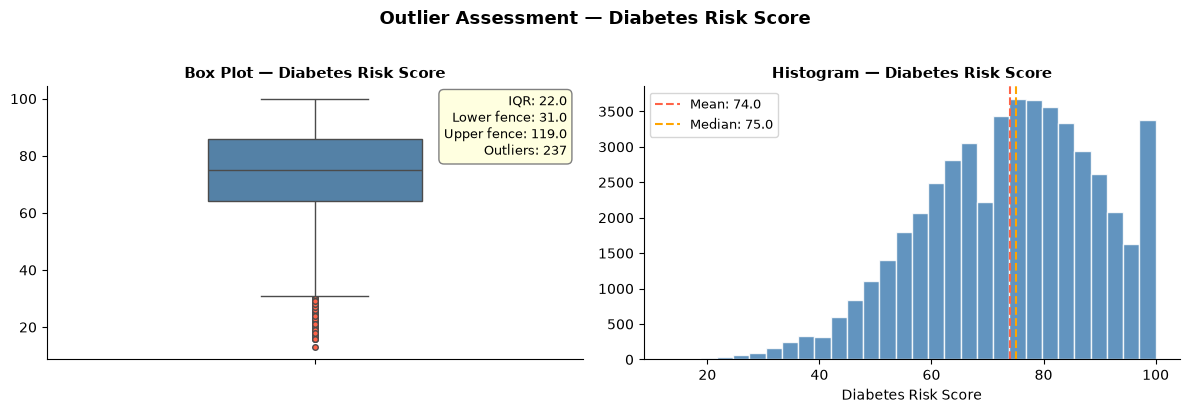

In [142]:
# Assessing Outliers on target feature
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box Plot
sns.boxplot(y=df_statistics['Diabetes_Risk_Score'], ax=axes[0], color='steelblue', width=0.4, flierprops=dict(marker='o', markerfacecolor='tomato', markersize=4, linestyle='none'))
axes[0].set_title('Box Plot — Diabetes Risk Score', fontsize=11, fontweight='bold')
axes[0].set_ylabel('')

q1 = df_statistics['Diabetes_Risk_Score'].quantile(0.25)
q3 = df_statistics['Diabetes_Risk_Score'].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
n_outliers = ((df_statistics['Diabetes_Risk_Score'] < lower_fence) | (df_statistics['Diabetes_Risk_Score'] > upper_fence)).sum()
axes[0].annotate(
    f'IQR: {iqr:.1f}\nLower fence: {lower_fence:.1f}\nUpper fence: {upper_fence:.1f}\nOutliers: {n_outliers}',
    xy=(0.97, 0.97), xycoords='axes fraction',
    ha='right', va='top', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray')
)

# Histogram
axes[1].hist(df_statistics['Diabetes_Risk_Score'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(df_statistics['Diabetes_Risk_Score'].mean(), color='tomato', linestyle='--', linewidth=1.5, label=f"Mean: {df_statistics['Diabetes_Risk_Score'].mean():.1f}")
axes[1].axvline(df_statistics['Diabetes_Risk_Score'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median: {df_statistics['Diabetes_Risk_Score'].median():.1f}")
axes[1].set_title('Histogram — Diabetes Risk Score', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Diabetes Risk Score')
axes[1].set_ylabel('')
axes[1].legend(fontsize=9)

plt.suptitle('Outlier Assessment — Diabetes Risk Score', fontsize=13, fontweight='bold', y=1.02)
sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()


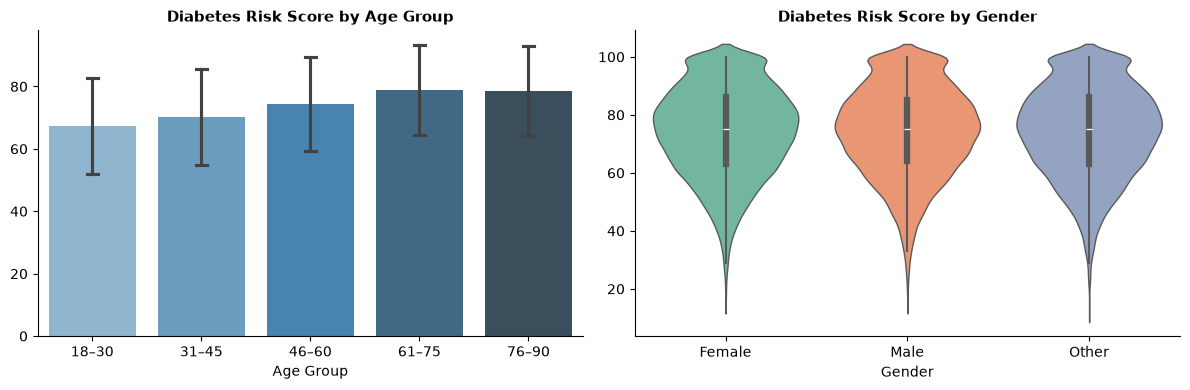

In [143]:
# Diabetes Risk Score by Age and Gender

age_bins = [17, 30, 45, 60, 75, 90]
age_labels = ['18–30', '31–45', '46–60', '61–75', '76–90']
df_statistics['Age_Group'] = pd.cut(df_statistics['Age'], bins=age_bins, labels=age_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age
sns.barplot(data=df_statistics, x='Age_Group', y='Diabetes_Risk_Score', palette='Blues_d', errorbar='sd', capsize=0.1, ax=axes[0])
axes[0].set_title('Diabetes Risk Score by Age Group', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('')

# Gender
sns.violinplot(data=df_statistics, x='Gender', y='Diabetes_Risk_Score', order=['Female', 'Male', 'Other'], palette='Set2', inner='box', linewidth=1, ax=axes[1])
axes[1].set_title('Diabetes Risk Score by Gender', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('')

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

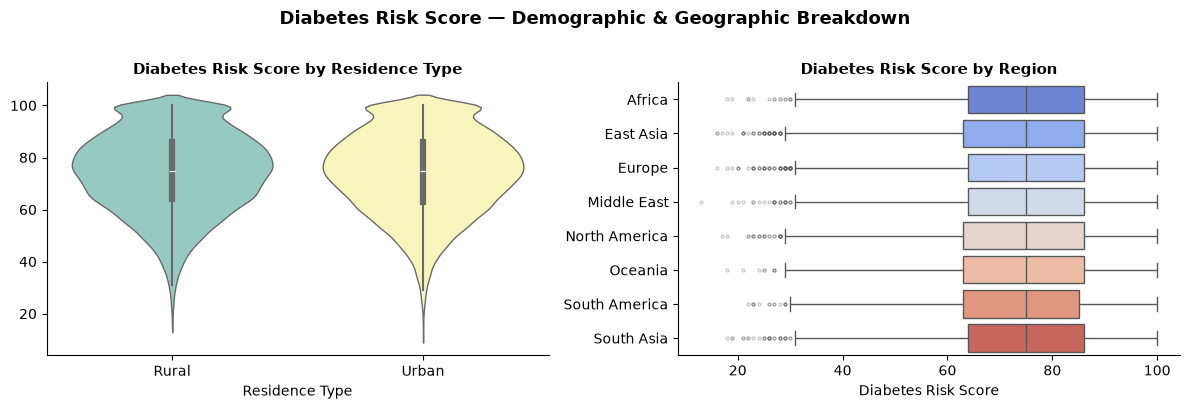

In [144]:
# Diabetes Risk Score by Residence Type and Region

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residence Type
sns.violinplot(data=df_statistics, x='Residence_Type', y='Diabetes_Risk_Score', palette='Set3', inner='box', linewidth=1, ax=axes[0])
axes[0].set_title('Diabetes Risk Score by Residence Type', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Residence Type')
axes[0].set_ylabel('')

# Region (sorted by median)
region_order = (df_statistics.groupby('Region')['Diabetes_Risk_Score'].median().sort_values(ascending=False).index.tolist())
sns.boxplot(data=df_statistics, y='Region', x='Diabetes_Risk_Score', order=region_order, palette='coolwarm',
flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=axes[1])

axes[1].set_title('Diabetes Risk Score by Region', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Diabetes Risk Score')
axes[1].set_ylabel('')

plt.suptitle('Diabetes Risk Score — Demographic & Geographic Breakdown',fontsize=13, fontweight='bold', y=1.01)

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

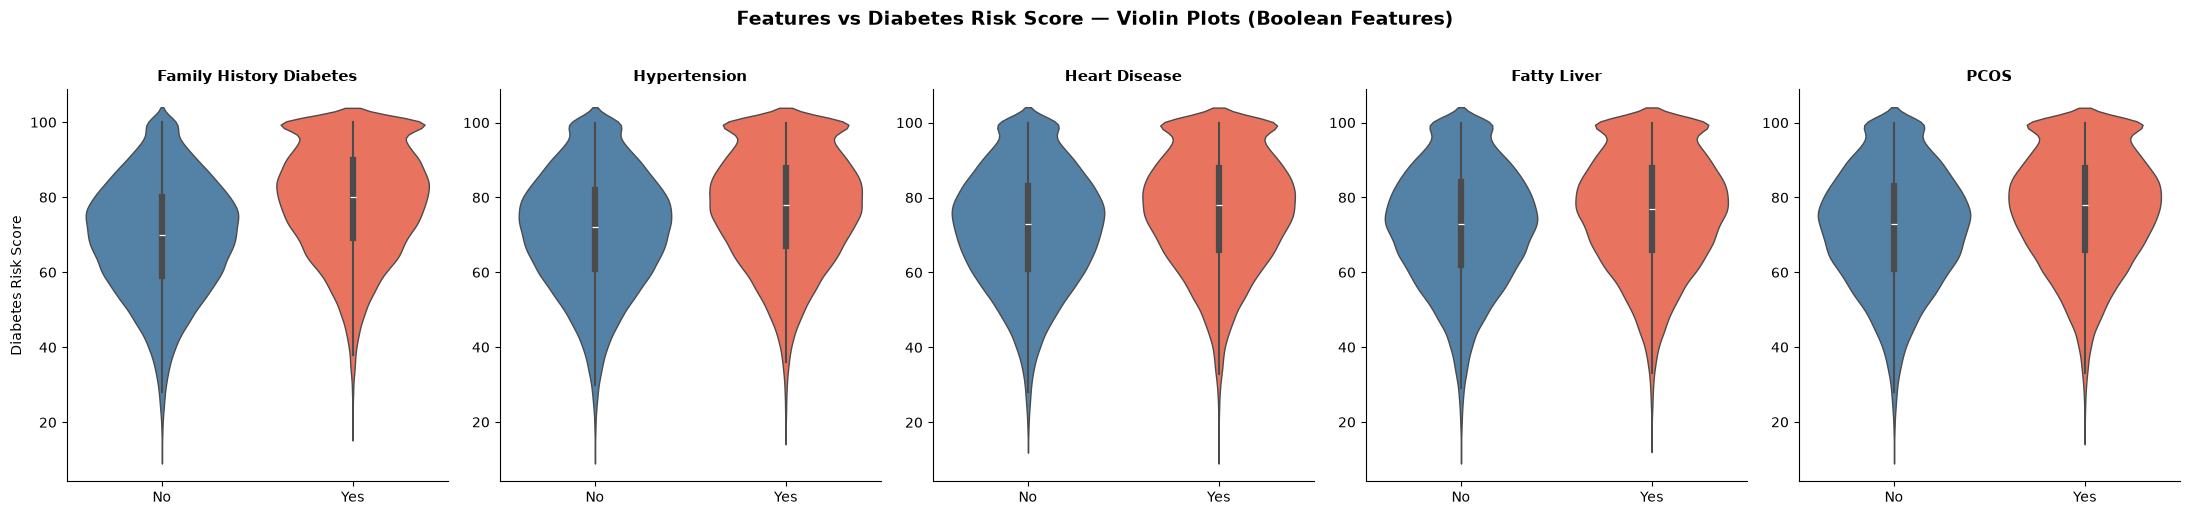

In [145]:
boolean_features = ['Family_History_Diabetes', 'Hypertension', 'Heart_Disease', 'Fatty_Liver', 'PCOS'
]

# Violin plots (boolean features)
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

label_map = {0: 'No', 1: 'Yes'}
for i, feat in enumerate(boolean_features):
    tmp = df_ml[[feat, 'Diabetes_Risk_Score']].copy()
    tmp[feat] = tmp[feat].map(label_map)
    sns.violinplot(
        data=tmp, x=feat, y='Diabetes_Risk_Score',
        order=['No', 'Yes'], palette={'No': 'steelblue', 'Yes': 'tomato'},
        inner='box', linewidth=1, ax=axes[i]
    )
    axes[i].set_title(feat.replace('_', ' '), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Diabetes Risk Score' if i == 0 else '')

fig.suptitle('Features vs Diabetes Risk Score — Violin Plots (Boolean Features)',
              fontsize=14, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()

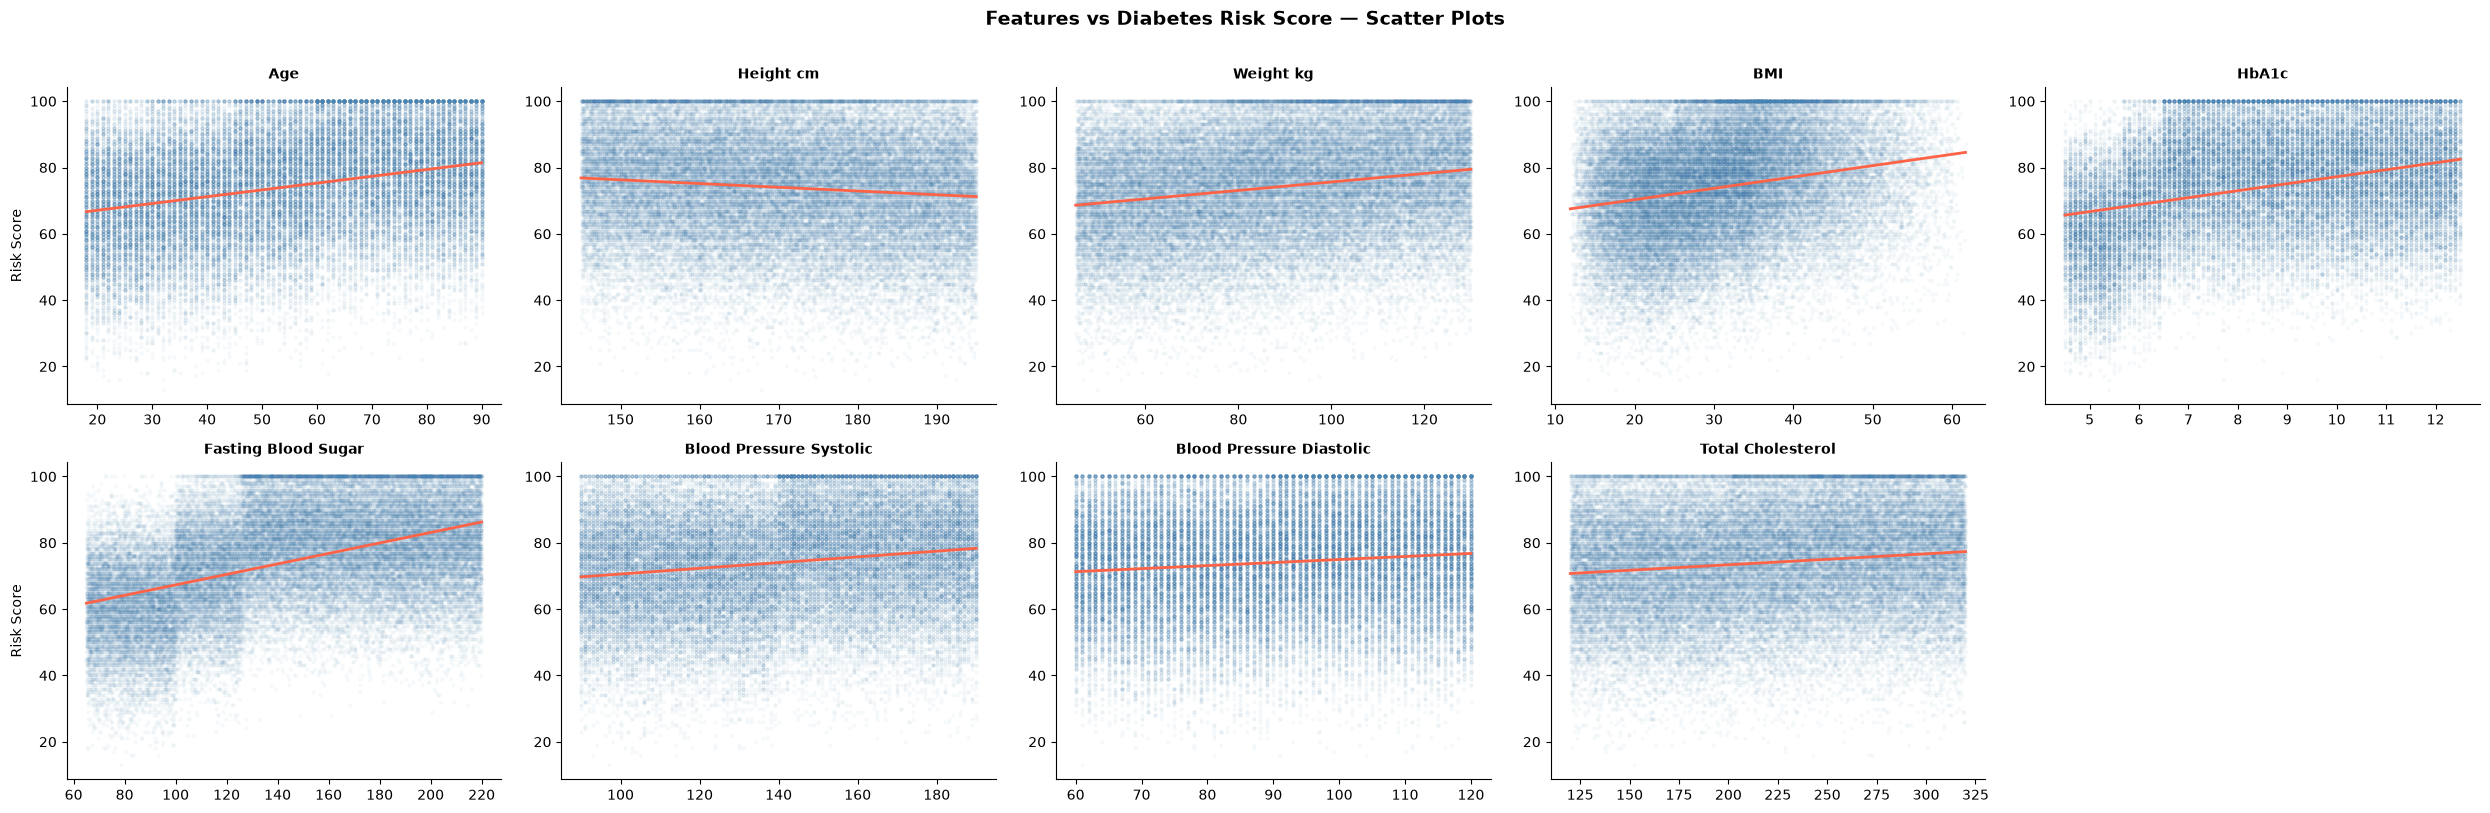

In [146]:
# Feature vs Diabetes Risk Score — Scatter plots

continuous_features = ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'HbA1c','Fasting_Blood_Sugar', 'Blood_Pressure_Systolic','Blood_Pressure_Diastolic', 'Total_Cholesterol']

all_scatter = continuous_features
n_cols = 5
n_rows = -(-len(all_scatter) // n_cols)

fig, axes1 = plt.subplots(n_rows, n_cols, figsize=(25, 8))
axes1 = axes1.flatten()

for i, feat in enumerate(all_scatter):
    ax = axes1[i]
    if feat in continuous_features:
        sns.regplot(
            data=df_ml, x=feat, y='Diabetes_Risk_Score', ax=ax,
            scatter_kws={'alpha': 0.03, 's': 5, 'color': 'steelblue'},
            line_kws={'color': 'tomato', 'linewidth': 2}
        )
    else:
        sns.stripplot(
            data=df_ml, x=feat, y='Diabetes_Risk_Score', ax=ax,
            alpha=0.05, size=3, color='steelblue', jitter=True
        )
        means = df_ml.groupby(feat)['Diabetes_Risk_Score'].mean()
        for x_pos, y_val in enumerate(means.values):
            ax.hlines(y_val, x_pos - 0.35, x_pos + 0.35,
                      colors='tomato', linewidths=2.5)
    ax.set_title(feat.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Risk Score' if i % n_cols == 0 else '')

for j in range(i + 1, len(axes1)):
    axes1[j].set_visible(False)

fig.suptitle('Features vs Diabetes Risk Score — Scatter Plots',
              fontsize=14, fontweight='bold', y=1.01)

sns.despine()
plt.tight_layout()

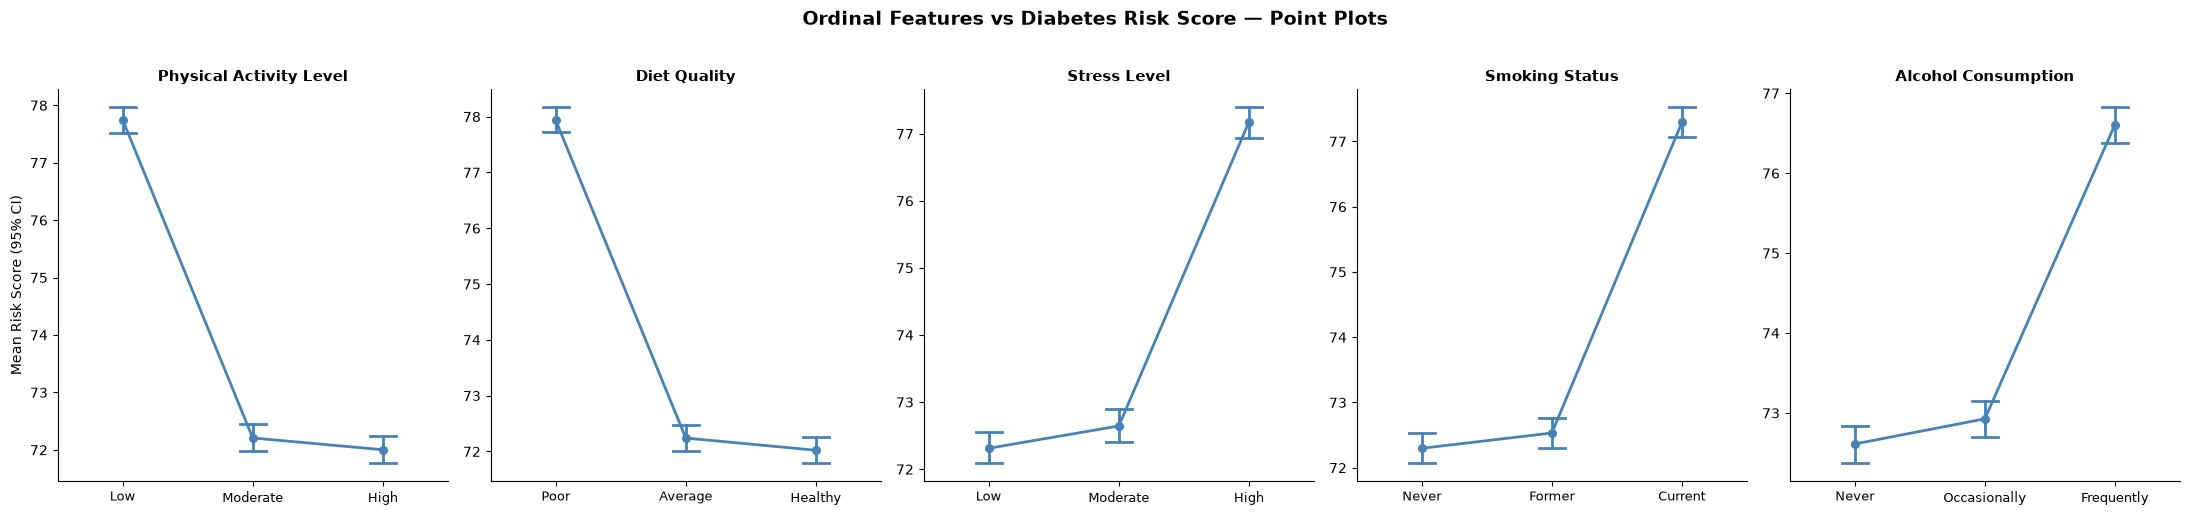

In [147]:
# Ordinal Features vs Diabetes Risk Score — Point Plots

ordinal_features = ['Physical_Activity_Level', 'Diet_Quality', 'Stress_Level','Smoking_Status', 'Alcohol_Consumption']

tick_labels = {
    'Physical_Activity_Level': ['Low', 'Moderate', 'High'],
    'Diet_Quality':            ['Poor', 'Average', 'Healthy'],
    'Stress_Level':            ['Low', 'Moderate', 'High'],
    'Smoking_Status':          ['Never', 'Former', 'Current'],
    'Alcohol_Consumption':     ['Never', 'Occasionally', 'Frequently'],
}

fig, axes = plt.subplots(1, len(ordinal_features), figsize=(22, 5))

for i, feat in enumerate(ordinal_features):
    ax = axes[i]
    sns.pointplot(
        data=df_ml, x=feat, y='Diabetes_Risk_Score',
        ax=ax, color='steelblue',
        markers='o', linestyles='-', linewidth=2,
        errorbar='ci', capsize=0.2
    )
    ax.set_xticks(range(len(tick_labels[feat])))
    ax.set_xticklabels(tick_labels[feat], fontsize=9)
    ax.set_title(feat.replace('_', ' '), fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Mean Risk Score (95% CI)' if i == 0 else '')

fig.suptitle('Ordinal Features vs Diabetes Risk Score — Point Plots',fontsize=14, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()

In [148]:
#Predictive Models

In [149]:
# Multicolineatiry Assessment and adjustments

In [150]:
# One-hot encoding for Work_Type and region to assess correlation
df_ml = pd.get_dummies(df_ml, columns=['Work_Type','Residence_Type','Region'],dtype=int)

In [151]:
# Filtering dataframe to assess multicolinearity and best features for target variables
corr_matrix = df_ml.corr(method='spearman')
target_corr = corr_matrix[['Diabetes_Risk_Score','Doctor_Consultation_Needed']]
corr_matrix_target = target_corr[((target_corr >= 0.1) | (target_corr <= -0.1))]

# Extracting feature names with non-NaN correlation for each target
features_diabetes_risk = corr_matrix_target['Diabetes_Risk_Score'].dropna().index.tolist()

# Dataframe to assess diabetes risk score
df_diabetes_risk = df_ml[features_diabetes_risk]
df_diabetes_risk.drop(['Diabetes_Risk','Doctor_Consultation_Needed'], axis=1, inplace=True)

# Dataframe to assess Doctor consultation needed
df_doctor_consultation = df_ml[['Doctor_Consultation_Needed','Diabetes_Risk_Score']]

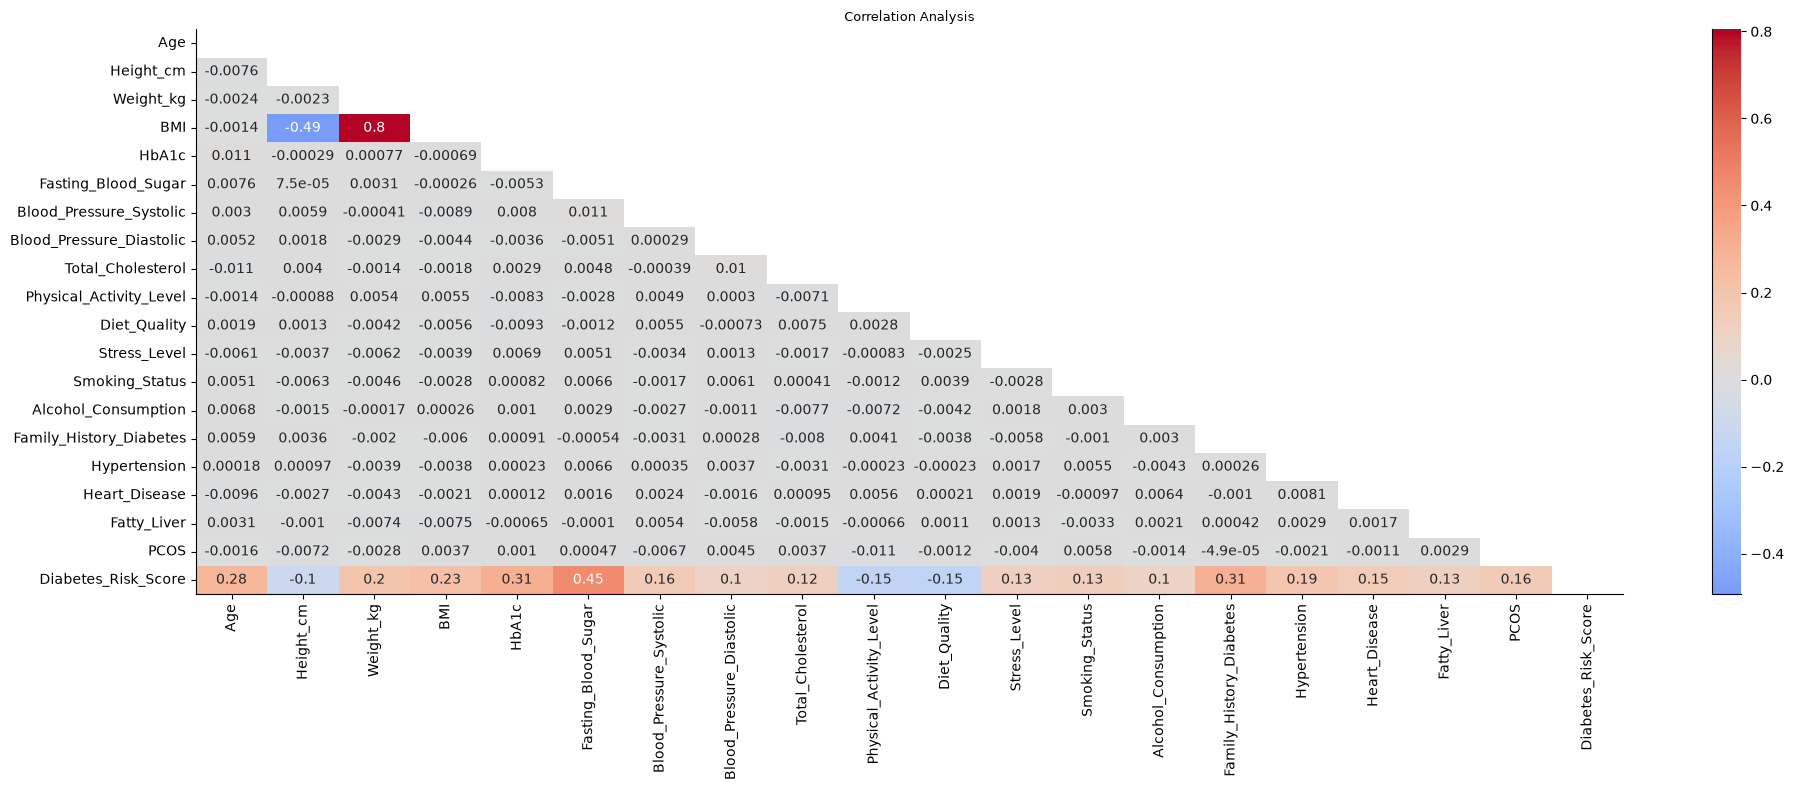

In [152]:
corr = df_diabetes_risk.corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) # Mask to remove the upper side and facilitate visualization

plt.figure(figsize=(20,8))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0)

sns.despine(left=False, right=True, top=True, bottom=False)

plt.title("Correlation Analysis", fontsize=9)
plt.tight_layout()

In [153]:
df_diabetes_risk.drop(['Height_cm', 'Weight_kg'], axis=1, inplace=True)

In [154]:
# OLS regression to Veirfy explainability and statistical significance of the features.
import statsmodels.api as sm

y = df_diabetes_risk['Diabetes_Risk_Score']
X = df_diabetes_risk.drop('Diabetes_Risk_Score', axis=1)

# Add a constant (intercept) to the model
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X)
results = model.fit()

# Print results
print(results.summary())

                             OLS Regression Results                            
Dep. Variable:     Diabetes_Risk_Score   R-squared:                       0.757
Model:                             OLS   Adj. R-squared:                  0.757
Method:                  Least Squares   F-statistic:                     9143.
Date:                 Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                         10:41:13   Log-Likelihood:            -1.7297e+05
No. Observations:                50000   AIC:                         3.460e+05
Df Residuals:                    49982   BIC:                         3.461e+05
Df Model:                           17                                         
Covariance Type:             nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const         

In [155]:
#Model training

In [156]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, max_error # Regression Model metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Classification metrics

In [157]:
# Regression training / Test split
y_reg = df_diabetes_risk['Diabetes_Risk_Score']
X_reg = df_diabetes_risk.drop('Diabetes_Risk_Score', axis=1)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42, shuffle=True)

# Classification training / Test split
y_clf = df_doctor_consultation['Doctor_Consultation_Needed']
X_clf = df_doctor_consultation.drop('Doctor_Consultation_Needed', axis=1)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42, shuffle=True)

In [158]:
# Function to get Regression Metrics
def reg_metrics(y_true, y_pred, round_digits=4):
    print("Evaluation Metrics:\n")

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    max_err = max_error(y_true, y_pred)

    print(f"R² Score: {r2:.{round_digits}f}")
    print(f"MAE: {mae:.{round_digits}f}")
    print(f"MAPE(%): {mape * 100:.{round_digits}f}%")
    print(f"Max Error: {max_err:.{round_digits}f}")

# Function to get Classification Metrics
def class_metrics(y_true, y_pred):
    print("Evaluation Metrics:\n")

    accuracy = accuracy_score(y_true, y_pred) * 100
    class_atrix = classification_report(y_true,y_pred)

    print(class_atrix)
    print("Accuracy: %.2f%%" % accuracy)

In [159]:
# Regression Models

In [160]:
# OLS regression - Baseline model
import statsmodels.api as sm

# Add a constant (intercept) to the model
X = sm.add_constant(X_train_reg)

# Fit the OLS model
model = sm.OLS(y_train_reg, X)
results = model.fit()

# Print results
print(results.summary())

                             OLS Regression Results                            
Dep. Variable:     Diabetes_Risk_Score   R-squared:                       0.755
Model:                             OLS   Adj. R-squared:                  0.755
Method:                  Least Squares   F-statistic:                     6349.
Date:                 Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                         10:41:13   Log-Likelihood:            -1.2115e+05
No. Observations:                35000   AIC:                         2.423e+05
Df Residuals:                    34982   BIC:                         2.425e+05
Df Model:                           17                                         
Covariance Type:             nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const         

In [161]:
from xgboost import XGBRegressor

# XGBoost
model_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
model_xgb.fit(X_train_reg, y_train_reg)

# 4. Predict and evaluate
y_pred_reg = model_xgb.predict(X_test_reg)
reg_metrics(y_test_reg, y_pred_reg, round_digits=2)

Evaluation Metrics:

R² Score: 0.95
MAE: 2.60
MAPE(%): 3.79%
Max Error: 23.56


In [162]:
# Classification Models

In [163]:
# Dummy Classifier - Base model
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy='stratified', random_state=42)
dummy_model.fit(X_train_clf, y_train_clf) # Train the model
y_pred_clf = dummy_model.predict(X_test_clf) # Make predictions

class_metrics(y_test_clf, y_pred_clf)

Evaluation Metrics:

              precision    recall  f1-score   support

           0       0.10      0.10      0.10      1107
           1       0.93      0.93      0.93     13893

    accuracy                           0.87     15000
   macro avg       0.51      0.51      0.51     15000
weighted avg       0.87      0.87      0.87     15000

Accuracy: 86.90%


In [164]:
# Assessing Imbalanced dataset
from imblearn.over_sampling import SMOTE

# Apply SMOTE to generate synthetic examples for the minority class
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_clf, y_clf)


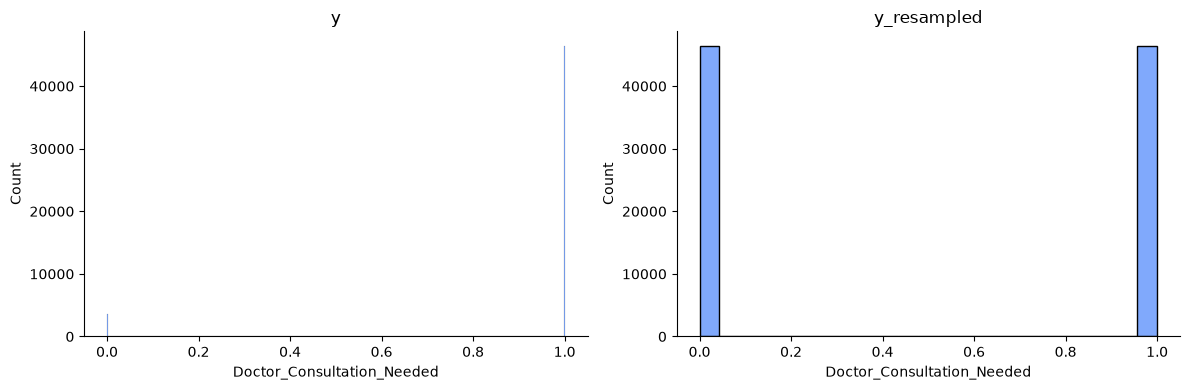

In [165]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0] = sns.histplot(y_clf, ax=axes[0])
axes[0].set_title("y")

axes[1] = sns.histplot(y_resampled, ax=axes[1])
axes[1].set_title("y_resampled")

plt.tight_layout()
sns.despine()

In [166]:
# Dummy Classifier - Base model now balanced
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42, shuffle=True)

dummy_model = DummyClassifier(strategy='stratified', random_state=42)
dummy_model.fit(X_train_clf, y_train_clf) # Train the model
y_pred_clf = dummy_model.predict(X_test_clf) # Make predictions

class_metrics(y_test_clf, y_pred_clf)

Evaluation Metrics:

              precision    recall  f1-score   support

           0       0.50      0.50      0.50     13917
           1       0.50      0.50      0.50     13939

    accuracy                           0.50     27856
   macro avg       0.50      0.50      0.50     27856
weighted avg       0.50      0.50      0.50     27856

Accuracy: 50.10%


In [167]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest classifier
random_forecast_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forecast_model.fit(X_train_clf, y_train_clf)
y_pred_clf = random_forecast_model.predict(X_test_clf) # Make predictions on the test set

# Evaluate the model's performance
class_metrics(y_test_clf, y_pred_clf)

Evaluation Metrics:

              precision    recall  f1-score   support

           0       0.82      1.00      0.90     13917
           1       1.00      0.78      0.88     13939

    accuracy                           0.89     27856
   macro avg       0.91      0.89      0.89     27856
weighted avg       0.91      0.89      0.89     27856

Accuracy: 89.05%


Confusion Matrix:
 [[13917     0]
 [ 3049 10890]]


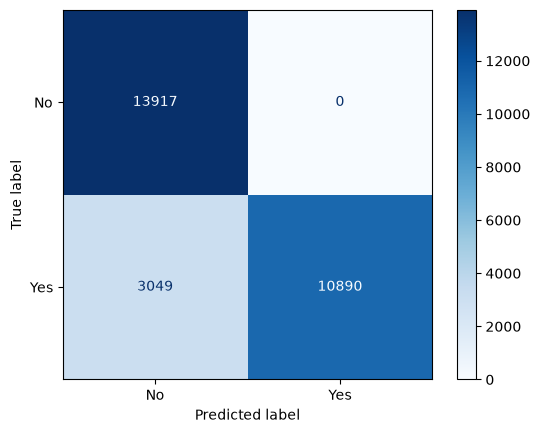

In [168]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
print("Confusion Matrix:\n", cm)

# Display visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(cmap='Blues')

In [169]:
# Making Predictions

In [170]:
# Inputs for Diabetes Risk Score
X_reg_features = X_reg.columns.to_list()
values = [32, 22, 15.4, 150.5, 94, 61, 138.7, 1, 2, 1, 1, 0, 1, 0, 1, 1, 0]
diabetes_risk_inputs = pd.DataFrame([dict(zip(X_reg_features, values))])
# Output for Diabetes Risk Score
diabetes_risk_score_prediction = model_xgb.predict(diabetes_risk_inputs)

# Inputs for Doctor consultation Needed
X_clf_features = X_clf.columns.to_list()
Doctor_consultation_inputs = pd.DataFrame([dict(zip(X_clf_features, diabetes_risk_score_prediction))])
# Output for Doctor consultation Needed
label_map = {0: "No", 1: "Yes"}
Doctor_consultation_prediction = label_map[random_forecast_model.predict(Doctor_consultation_inputs)[0]]


In [171]:
print(f"Diabetes Risk Score: {diabetes_risk_score_prediction[0]:,.2f}")
print(f"Doctor Consultation: {Doctor_consultation_prediction}")

Diabetes Risk Score: 62.85
Doctor Consultation: No
